# 3 — RESTORE: per-image marker positivity

Calls the cells positive for a marker, per donor.

- features are **Cytoplasm and Membrane** — disjoint regions. `Cell` is not used: it is a superset
  containing the membrane band, so it is collinear with it (r 0.84–0.96) and adds no information.
- a cell needs **both a nucleus and a cell body** to have a cytoplasm; cells without one are dropped.
- **every cell**, no subsampling.
- **no clipping** — the bright population is the signal.

**These are RAW QuPath compartment means, not REDSEA.** `qupath_compartment_full_20donor` was
extracted from the QuPath measurement CSVs, which are pre-REDSEA: `Cell__<marker>` matches
`data/cells` at r=1.000000 (max delta 5e-05) and `data/cells_redsea` at r=0.974 (max delta 12,816).
REDSEA emits a corrected whole-cell mean only — there is no REDSEA-corrected Nucleus, Cytoplasm or
Membrane — so compartment features and spillover correction cannot currently be had together.




## 1 — Load Cytoplasm and Membrane for every cell



In [ ]:
import sys, glob, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
%matplotlib inline
warnings.filterwarnings('ignore')


In [2]:
REPO    = pathlib.Path.cwd().resolve().parents[1]     # Islet-Explorer-Senior (data/ lives here)
COMPART = REPO/'data'/'restore_pair_validation'/'qupath_compartment_full_20donor'
REDSEA  = REPO/'data'/'cells_redsea'

DONOR  = '6566'
MARKER = 'CD11b'

print('donor', DONOR, '| marker', MARKER)


donor 6566 | marker CD11b


In [3]:
f = glob.glob(str(COMPART/f'donor_id={DONOR}'/'*.parquet'))[0]
cy, mb = f'Cytoplasm__{MARKER}', f'Membrane__{MARKER}'
d = pd.read_parquet(f, columns=['object_id', cy, mb])
n_all = len(d)

# a cell needs both a nucleus and a cell body to have a cytoplasm
keep = np.isfinite(d[cy]) & np.isfinite(d[mb]) & (d[cy] >= 0) & (d[mb] >= 0)
d = d[keep].reset_index(drop=True)
C = d[cy].to_numpy(float)
M = d[mb].to_numpy(float)
print(f'{n_all:,} cells   ->  {len(d):,} with a cytoplasm   ({n_all-len(d):,} dropped)')
print(f'  Cytoplasm  median {np.median(C):8.1f}   max {C.max():9.1f}')
print(f'  Membrane   median {np.median(M):8.1f}   max {M.max():9.1f}')



1,781,276 cells   ->  1,621,163 with a cytoplasm   (160,113 dropped)
  Cytoplasm  median    654.5   max   44908.7
  Membrane   median    646.6   max   34961.4


## 2 — The two distributions



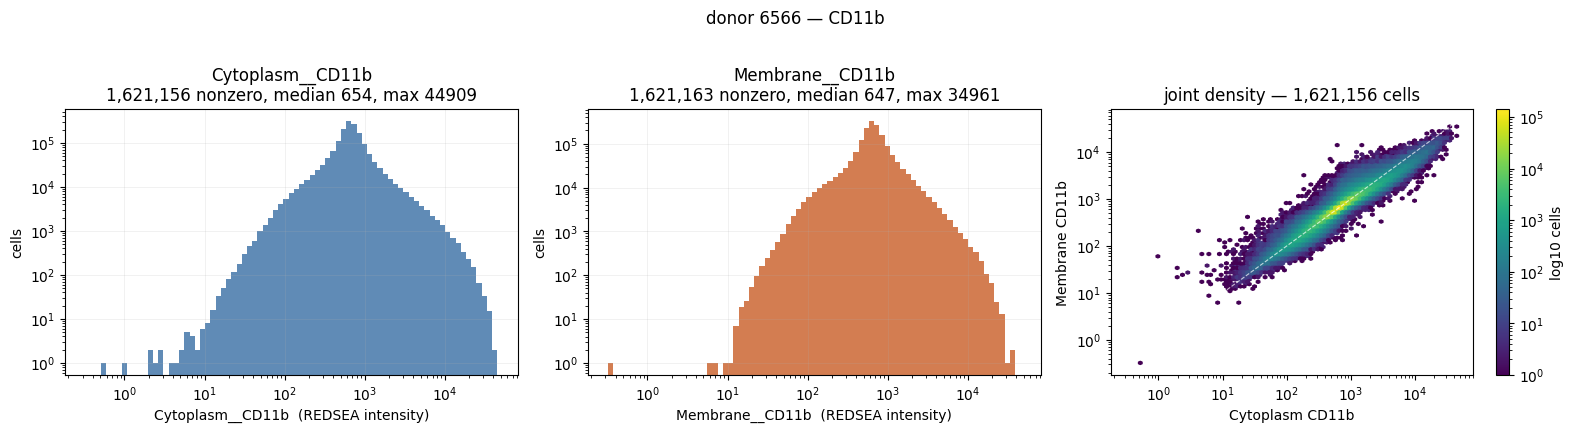

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

# --- the two compartment distributions, log intensity, log counts -------------------------------
bins = np.logspace(np.log10(max(min(C[C>0].min(), M[M>0].min()), 1e-3)),
                   np.log10(max(C.max(), M.max())), 80)
for a, (nm, x, colr) in zip(ax[:2], ((cy, C, '#4477AA'), (mb, M, '#CC6633'))):
    a.hist(x[x > 0], bins=bins, color=colr, alpha=.85)
    a.set_xscale('log'); a.set_yscale('log')
    a.set_xlabel(f'{nm}  (raw QuPath mean)'); a.set_ylabel('cells')
    a.set_title(f'{nm}\n{(x>0).sum():,} nonzero, median {np.median(x[x>0]):.0f}, max {x.max():.0f}')
    a.grid(alpha=.25, lw=.5)

# --- the joint density: where a cell sits in both compartments at once --------------------------
both = (C > 0) & (M > 0)
hb = ax[2].hexbin(C[both], M[both], xscale='log', yscale='log', gridsize=90,
                  bins='log', cmap='viridis', mincnt=1)
lim = [min(C[both].min(), M[both].min()), max(C.max(), M.max())]
ax[2].plot(lim, lim, color='w', lw=.8, ls='--', alpha=.7)
ax[2].set_xlabel(f'Cytoplasm {MARKER}'); ax[2].set_ylabel(f'Membrane {MARKER}')
ax[2].set_title(f'joint density — {both.sum():,} cells')
fig.colorbar(hb, ax=ax[2], label='log10 cells')

fig.suptitle(f'donor {DONOR} — {MARKER}', y=1.02)
plt.tight_layout(); plt.show()



## 3 — Boundary in each compartment

Find the peak of the dim bulk, then walk right to the first local minimum in the smoothed density.
A cell is called positive when it is above the boundary in **both** compartments.



In [ ]:
def find_boundary(values, bins=160, smooth=7):
    """Boundary between the dim bulk and the bright population, from this donor's own histogram."""
    p = values[values > 0]
    if p.size < 100: return np.nan, {}
    lp = np.log10(p)
    hh, ee = np.histogram(lp, bins=bins, range=(lp.min(), lp.max()))
    c = 0.5*(ee[:-1]+ee[1:])
    s = uniform_filter1d(hh.astype(float), size=smooth)
    mode = int(np.argmax(s))
    for i in range(mode+3, len(s)-3):
        if s[i] <= s[i-1] and s[i] <= s[i+1]:
            return 10**c[i], dict(mode=10**c[mode], centers=c, smooth=s)
    return np.nan, dict(mode=10**c[mode], centers=c, smooth=s)

tC, gC = find_boundary(C)
tM, gM = find_boundary(M)
is_pos = (C > tC) & (M > tM)
print(f'Cytoplasm  bulk peak {gC.get("mode", float("nan")):9.1f}   boundary {tC:9.1f}   above: {(C>tC).sum():,}')
print(f'Membrane   bulk peak {gM.get("mode", float("nan")):9.1f}   boundary {tM:9.1f}   above: {(M>tM).sum():,}')
print(f'\npositive in BOTH: {is_pos.sum():,}  ({is_pos.mean()*100:.4f}% of {len(d):,})')



In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16,4.4))
for a, (nm, x, t, g) in zip(ax, ((cy, C, tC, gC), (mb, M, tM, gM))):
    a.step(g['centers'], g['smooth'], where='mid', color='#333', lw=1)
    a.fill_between(g['centers'], g['smooth'], step='mid', alpha=.2, color='#777')
    a.axvline(np.log10(g['mode']), color='#4477AA', lw=2, label=f"bulk {g['mode']:.0f}")
    if np.isfinite(t): a.axvline(np.log10(t), color='#EE6677', lw=2, label=f'boundary {t:.0f}')
    a.set_yscale('log'); a.set_title(nm); a.set_xlabel('log10 intensity'); a.legend(fontsize=8)
s = np.random.default_rng(0).choice(len(C), min(200_000, len(C)), replace=False)  # plotting only
ax[2].scatter(np.log10(C[s]+1), np.log10(M[s]+1), s=1, c=np.where(is_pos[s], '#EE6677', '#BBBBBB'), alpha=.3)
if np.isfinite(tC): ax[2].axvline(np.log10(tC+1), color='#EE6677', lw=1)
if np.isfinite(tM): ax[2].axhline(np.log10(tM+1), color='#EE6677', lw=1)
ax[2].set_xlabel(f'log10 Cytoplasm {MARKER}'); ax[2].set_ylabel(f'log10 Membrane {MARKER}')
ax[2].set_title(f'{is_pos.sum():,} positive')
plt.tight_layout(); plt.show()



## 4 — Check the calls on the image

Import with `scripts/groovy/import_broad_lineage.groovy` — it matches on the QuPath detection UUID
(`object_id`) — and compare the called cells against the channel.



In [ ]:
outdir = REPO/'data'/'positivity'/MARKER
outdir.mkdir(parents=True, exist_ok=True)
out = pd.DataFrame({'object_id': d['object_id'].astype(str),
                    'Cytoplasm': C, 'Membrane': M, f'{MARKER}_pos': is_pos})
dst = outdir/f'{MARKER}_{DONOR}.csv'
out.to_csv(dst, index=False)
print(f'{dst}\n{is_pos.sum():,} positive of {len(out):,}')
out[out[f'{MARKER}_pos']].head()



## 5 — This marker across every donor



In [ ]:
rows = []
for p in sorted(glob.glob(str(COMPART/'donor_id=*'))):
    dn = p.split('donor_id=')[1]
    dd = pd.read_parquet(glob.glob(p+'/*.parquet')[0], columns=[cy, mb])
    k  = np.isfinite(dd[cy]) & np.isfinite(dd[mb]) & (dd[cy] >= 0) & (dd[mb] >= 0)
    c2, m2 = dd.loc[k, cy].to_numpy(float), dd.loc[k, mb].to_numpy(float)
    t1, _ = find_boundary(c2); t2, _ = find_boundary(m2)
    n = int(((c2 > t1) & (m2 > t2)).sum())
    rows.append(dict(donor=dn, n_cells=int(k.sum()), cyto_boundary=round(t1,1), memb_boundary=round(t2,1),
                     n_positive=n, pct=round(n/max(int(k.sum()),1)*100, 4)))
    print(f"  {dn}: {n:>8,} positive   cyto {rows[-1]['cyto_boundary']}  memb {rows[-1]['memb_boundary']}", flush=True)
per_donor = pd.DataFrame(rows)
per_donor



In [ ]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].bar(per_donor.donor, per_donor.cyto_boundary, color='#4477AA', label='Cytoplasm')
ax[0].bar(per_donor.donor, per_donor.memb_boundary, color='#CC6633', alpha=.6, label='Membrane')
ax[0].set_title(f'{MARKER} boundaries per donor'); ax[0].legend(); ax[0].tick_params(axis='x', rotation=90)
ax[1].bar(per_donor.donor, per_donor.n_positive.clip(lower=1), color='#228833'); ax[1].set_yscale('log')
ax[1].set_title(f'{MARKER}+ cells per donor'); ax[1].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()



## 6 — Every marker with Cytoplasm and Membrane measurements, this donor



In [ ]:
full  = pd.read_parquet(f)
marks = sorted({c.split('__',1)[1] for c in full.columns if c.startswith('Cytoplasm__')}
               & {c.split('__',1)[1] for c in full.columns if c.startswith('Membrane__')})
rows = []
for m in marks:
    a, b = full[f'Cytoplasm__{m}'].to_numpy(float), full[f'Membrane__{m}'].to_numpy(float)
    k = np.isfinite(a) & np.isfinite(b) & (a >= 0) & (b >= 0)
    a, b = a[k], b[k]
    t1, _ = find_boundary(a); t2, _ = find_boundary(b)
    n = int(((a > t1) & (b > t2)).sum())
    rows.append(dict(marker=m, n_cells=len(a), cyto_boundary=round(t1,1), memb_boundary=round(t2,1),
                     n_positive=n, pct=round(n/max(len(a),1)*100, 4)))
panel = pd.DataFrame(rows).sort_values('pct', ascending=False)
print(f'donor {DONOR}: {len(panel)} markers with both compartments')
panel

